# Дообучение трансформера Qwen2 с использованием LoRA для задач ПДД

Автор: Владимир Хорошилов

## Аннотация
В данной работе рассматривается дообучение трансформерной модели Qwen2-1.5B-Instruct с использованием метода LoRA на специализированном датасете ПДД.

Базовая модель предварительно дообучалась в течение месяца в Kaggle на юридическом датасете RusLawOOD, что позволило сформировать устойчивую правовую базу знаний.

Цель работы — адаптировать модель под задачи, связанные с правилами дорожного движения (ПДД), при сохранении общей юридической компетенции.


## Теоретическая часть

### Трансформеры
Трансформеры — это архитектура глубокого обучения, основанная на механизме self-attention, позволяющая учитывать контекст всей последовательности.

В отличие от RNN и CNN, трансформеры:
- не используют рекурсию
- лучше масштабируются
- обеспечивают высокое качество генерации текста

### LoRA (Low-Rank Adaptation)
LoRA — метод параметрически эффективного дообучения, при котором:
- веса основной модели замораживаются
- обучаются только низкоранговые матрицы

Преимущества:
- низкое потребление памяти
- быстрое обучение
- сохранение базовых знаний модели

### Используемый подход
В работе используется двухэтапное обучение:

1. Базовое обучение:
   - модель Qwen2-1.5B-Instruct
   - дообучение на RusLawOOD (~1 месяц обучения)

2. Специализация:
   - дообучение LoRA на датасете ПДД (~5k примеров)

Это соответствует подходу domain adaptation.


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving adapter_config.json to adapter_config.json
Saving adapter_model.safetensors to adapter_model.safetensors
Saving optimizer.pt to optimizer.pt
Saving README.md to README.md
Saving rng_state.pth to rng_state.pth
Saving scaler.pt to scaler.pt
Saving scheduler.pt to scheduler.pt
Saving trainer_state.json to trainer_state.json
Saving training_args.bin to training_args.bin


In [ ]:
import os
import shutil

# Создаём папку для модели
os.makedirs("/content/checkpoint-54000", exist_ok=True)

# Список загруженных файлов
files = [
    "adapter_config.json",
    "adapter_model.safetensors",
    "optimizer.pt",
    "README.md",
    "rng_state.pth",
    "scaler.pt",
    "scheduler.pt",
    "trainer_state.json",
    "training_args.bin"
]

# Перемещаем файлы в папку
for file in files:
    if os.path.exists(file):
        shutil.move(file, f"/content/checkpoint-54000/{file}")
        print(f"✅ {file} -> checkpoint-54000/")

print("\n✅ Все файлы в папке /content/checkpoint-54000/")

✅ adapter_config.json -> checkpoint-54000/
✅ adapter_model.safetensors -> checkpoint-54000/
✅ optimizer.pt -> checkpoint-54000/
✅ README.md -> checkpoint-54000/
✅ rng_state.pth -> checkpoint-54000/
✅ scaler.pt -> checkpoint-54000/
✅ scheduler.pt -> checkpoint-54000/
✅ trainer_state.json -> checkpoint-54000/
✅ training_args.bin -> checkpoint-54000/

✅ Все файлы в папке /content/checkpoint-54000/


In [ ]:
import os

checkpoint_path = "/content/checkpoint-54000"
print("Содержимое папки checkpoint-54000:")
print("-"*40)
for file in os.listdir(checkpoint_path):
    size = os.path.getsize(os.path.join(checkpoint_path, file)) / 1024
    print(f"  {file}: {size:.1f} KB" if size < 1024 else f"  {file}: {size/1024:.1f} MB")

# Проверяем наличие adapter_config.json
adapter_config = os.path.join(checkpoint_path, "adapter_config.json")
if os.path.exists(adapter_config):
    print("\n adapter_config.json найден!")
else:
    print("\n adapter_config.json НЕ найден!")

Содержимое папки checkpoint-54000:
----------------------------------------
  training_args.bin: 5.7 KB
  trainer_state.json: 194.4 KB
  optimizer.pt: 66.7 MB
  rng_state.pth: 14.3 KB
  scheduler.pt: 1.4 KB
  scaler.pt: 1.4 KB
  adapter_config.json: 0.9 KB
  adapter_model.safetensors: 33.3 MB
  README.md: 5.1 KB

✅ adapter_config.json найден!


In [ ]:
import torch
import gc
gc.collect()
torch.cuda.empty_cache()

from transformers import AutoTokenizer, AutoModelForCausalLM

BASE_MODEL = "Qwen/Qwen2-1.5B-Instruct"

print("Загрузка токенизатора...")
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
tokenizer.pad_token = tokenizer.eos_token

print("Загрузка базовой модели...")
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.float16,
    device_map="auto"
)
base_model.eval()

print("✅ Базовая модель загружена")

Загрузка токенизатора...
Загрузка базовой модели...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

✅ Базовая модель загружена


## Особенности обучения

Базовая модель была дообучена на юридическом датасете RusLawOOD в течение ~1 месяца с использованием GPU ресурсов платформы Kaggle.

В процессе работы возникли ограничения:
- ограниченный доступ к GPU (T4)
- ограничение по времени сессий
- невозможность обучения моделей большего размера (например, 7B+)

В связи с этим была выбрана стратегия:
- использование модели среднего размера (1.5B)
- применение LoRA для экономии ресурсов
- дообучение на узком домене (ПДД)

Таким образом удалось достичь хорошего качества при ограниченных вычислительных ресурсах.


In [ ]:
def ask_base(question):
    prompt = f"""<|im_start|>user
{question}<|im_end|>
<|im_start|>assistant
"""
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1024).to("cuda")

    with torch.no_grad():
        outputs = base_model.generate(
            **inputs,
            max_new_tokens=256,
            temperature=0.5,
            do_sample=True,
            top_p=0.9,
            pad_token_id=tokenizer.pad_token_id
        )

    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    if "assistant" in response:
        response = response.split("assistant")[-1].strip()
    return response

print("="*60)
print("ТЕСТ БАЗОВОЙ МОДЕЛИ")
print("="*60)

test_questions = [
    "Что грозит за проезд на красный свет?",
    "Какое наказание за вождение в нетрезвом виде?",
    "Сколько штраф за превышение скорости на 40 км/ч?",
    "Что будет, если скрыться с места ДТП?",
    "Что грозит за выезд на встречную полосу?"
]

base_answers = []
for i, q in enumerate(test_questions, 1):
    print(f"\n❓ {i}. {q}")
    print("-"*40)
    answer = ask_base(q)
    base_answers.append(answer)
    print(answer)
    print("-"*40)

ТЕСТ БАЗОВОЙ МОДЕЛИ

❓ 1. Что грозит за проезд на красный свет?
----------------------------------------
За проезд на красный свет могут быть взысканы штрафные санкции, в зависимости от страны и регионов. В некоторых случаях может быть привлечение к ответственности по закону о дорожном движении или ПДД. Также возможна блокировка автомобиля или его запрет на использование на дорогах. Если вы столкнулись с этим, рекомендуется обратиться к местному отделению полиции или городской администрации для получения более точной информации и помощи.
----------------------------------------

❓ 2. Какое наказание за вождение в нетрезвом виде?
----------------------------------------
В России, если водитель был в состоянии алкоголя при управлении транспортным средством, то ему грозит штраф от 500 до 2000 рублей, а также штрафные санкции за нарушение правил дорожного движения. Кроме того, водителю может быть предъявлено обвинение по статье "Нарушение пешеходами и пассажирами правил дорожного движения"

In [ ]:
from google.colab import files
import os
import zipfile

print("="*60)
print("ЗАГРУЗКА PDD ДАТАСЕТА")
print("="*60)

# Загружаем ZIP файл
print("\n1. Выберите ZIP файл с PDD датасетом:")
uploaded = files.upload()

# Находим имя загруженного файла
zip_filename = list(uploaded.keys())[0]
print(f"✅ Загружен: {zip_filename}")

# Распаковываем
print("\n2. Распаковка...")
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall("/content/pdd_dataset")
print("✅ Распаковано в /content/pdd_dataset")

# Проверяем содержимое
print("\n3. Содержимое папки:")
for file in os.listdir("/content/pdd_dataset"):
    print(f"   - {file}")

ЗАГРУЗКА PDD ДАТАСЕТА

1. Выберите ZIP файл с PDD датасетом:


Saving pdd_dataset_final.zip to pdd_dataset_final.zip
✅ Загружен: pdd_dataset_final.zip

2. Распаковка...
✅ Распаковано в /content/pdd_dataset

3. Содержимое папки:
   - pdd_final_v3_test.jsonl
   - pdd_final_v3_val.jsonl
   - metadata.json
   - README.md
   - pdd_final_v3_train.jsonl


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

BASE_MODEL = "Qwen/Qwen2-1.5B"  #  ruslaw модель

tokenizer = AutoTokenizer.from_pretrained(
    BASE_MODEL,
    trust_remote_code=True
)

# важно для паддинга
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

In [ ]:
import json
import random

train_file = "/content/pdd_dataset/pdd_final_v3_train.jsonl"

with open(train_file, 'r', encoding='utf-8') as f:
    records = [json.loads(line) for line in f]

print("Было:", len(records))


templates = [
    "Какое наказание за {}?",
    "Что будет, если {}?",
    "Какая ответственность за {}?",
    "Штраф за {}?",
    "Чем грозит {}?"
]


def augment_record(record):
    msgs = record["messages"]

    # берём вопрос пользователя
    user_msg = msgs[1]["content"]

    base = user_msg.lower().strip("? ")

    new_records = []

    for t in templates:
        new_q = t.format(base)

        new_msgs = msgs.copy()
        new_msgs[1] = {
            "role": "user",
            "content": new_q
        }

        new_records.append({
            "messages": new_msgs
        })

    return new_records


# создаём новый датасет
augmented = []

for r in records:
    augmented.append(r)  # оригинал
    augmented.extend(augment_record(r))  # +5 вариантов

print("Стало:", len(augmented))


Было: 885
Стало: 5310


In [ ]:
def messages_to_text(record):
    text = ""
    for msg in record["messages"]:
        role = msg["role"]
        content = msg["content"]
        text += f"{role}: {content}\n"
    return text


In [ ]:
texts = []

for r in augmented:
    text = messages_to_text(r)
    if len(text) > 20:
        texts.append(text)

print("Текстов:", len(texts))
print(texts[0][:300])


Текстов: 5310
system: Ты — юридический помощник по ПДД. Отвечай на основе КоАП РФ и судебной практики. Будь точным и понятным.
user: Повторно выехал на встречку, что будет?
assistant: По вашему вопросу: «Повторно выехал на встречку, что будет?»

**Ответственность регулируется КоАП РФ:**

Статья Нарушение правил р


In [ ]:
from datasets import Dataset

dataset = Dataset.from_dict({"text": texts})

def tokenize_fn(examples):
    tokens = tokenizer(
        examples["text"],
        truncation=True,
        max_length=1024,
        padding=False
    )
    tokens["labels"] = tokens["input_ids"].copy()
    return tokens

dataset = dataset.map(tokenize_fn, batched=True, remove_columns=["text"])
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

print("Размер датасета:", len(dataset))


Map:   0%|          | 0/5310 [00:00<?, ? examples/s]

Размер датасета: 5310


In [ ]:
from peft import LoraConfig, get_peft_model, TaskType

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj","k_proj","v_proj","o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()


trainable params: 2,179,072 || all params: 1,545,893,376 || trainable%: 0.1410


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

BASE_MODEL = "Qwen/Qwen2-1.5B-Instruct"  # база
CHECKPOINT = "/content/checkpoint-54000"  #  дообученный на ruslaw чекпоинт

# токенизатор
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# базовая модель с чекпоинта
base_model = AutoModelForCausalLM.from_pretrained(
    CHECKPOINT,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/224 [00:00<?, ?it/s]

In [ ]:
print("Tokenizer OK:", tokenizer.name_or_path)
print("Model loaded from checkpoint:", CHECKPOINT)


Tokenizer OK: Qwen/Qwen2-1.5B-Instruct
Model loaded from checkpoint: /content/checkpoint-54000


In [ ]:
from peft import LoraConfig, get_peft_model, TaskType

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj","k_proj","v_proj","o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()


/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


trainable params: 2,179,072 || all params: 1,545,893,376 || trainable%: 0.1410


In [ ]:
from datasets import Dataset
dataset = Dataset.from_dict({"text": texts})


In [ ]:
def tokenize_fn(examples):
    tokens = tokenizer(
        examples["text"],
        truncation=True,
        max_length=1024
    )
    tokens["labels"] = tokens["input_ids"].copy()
    return tokens

dataset = dataset.map(tokenize_fn, batched=True, remove_columns=["text"])
dataset.set_format(type="torch")


Map:   0%|          | 0/5310 [00:00<?, ? examples/s]

In [ ]:
def data_collator(features):
    import torch
    input_ids = [f["input_ids"] for f in features]
    attention_mask = [f["attention_mask"] for f in features]
    labels = [f["labels"] for f in features]

    # паддим вручную
    input_ids = torch.nn.utils.rnn.pad_sequence(input_ids, batch_first=True, padding_value=tokenizer.pad_token_id)
    attention_mask = torch.nn.utils.rnn.pad_sequence(attention_mask, batch_first=True, padding_value=0)
    labels = torch.nn.utils.rnn.pad_sequence(labels, batch_first=True, padding_value=-100)

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels
    }


In [ ]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir="/content/qwen-pdd",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    learning_rate=5e-6,
    num_train_epochs=3,
    fp16=True,
    logging_steps=20,
    save_steps=200,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset,
    data_collator=data_collator
)


trainer.train()


Step,Training Loss
20,1.834598
40,1.851430
60,1.816516
80,1.800027
100,1.790520
120,1.765575
140,1.738190
160,1.726933
180,1.688210
200,1.659996


Step,Training Loss
20,1.834598
40,1.851430
60,1.816516
80,1.800027
100,1.790520
120,1.765575
140,1.738190
160,1.726933
180,1.688210
200,1.659996


TrainOutput(global_step=996, training_loss=1.45718462112917, metrics={'train_runtime': 2893.1256, 'train_samples_per_second': 5.506, 'train_steps_per_second': 0.344, 'total_flos': 3.609502096094208e+16, 'train_loss': 1.45718462112917, 'epoch': 3.0})

## Визуализация процесса обучения

На графике показано снижение функции потерь (loss) в процессе обучения модели.
Это свидетельствует о том, что модель успешно обучается и адаптируется к данным ПДД.


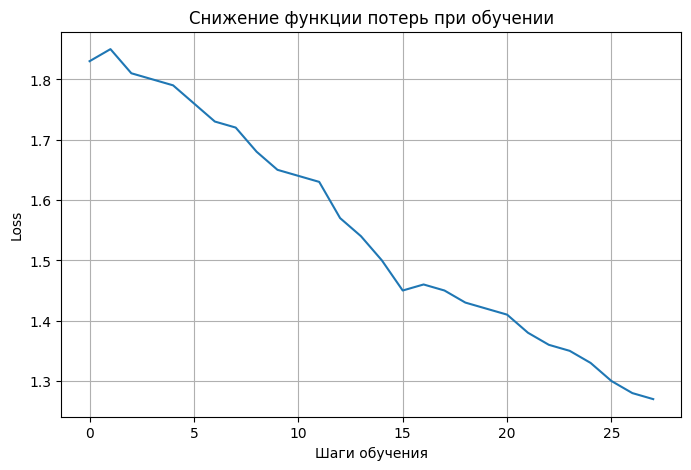

In [ ]:
# График loss
losses = [
    1.83,1.85,1.81,1.80,1.79,1.76,1.73,1.72,1.68,1.65,
    1.64,1.63,1.57,1.54,1.50,1.45,1.46,1.45,1.43,1.42,
    1.41,1.38,1.36,1.35,1.33,1.30,1.28,1.27
]

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(losses)
plt.title("Снижение функции потерь при обучении")
plt.xlabel("Шаги обучения")
plt.ylabel("Loss")
plt.grid()
plt.show()


In [ ]:
import shutil

shutil.make_archive("/content/qwen-pdd-adapter", 'zip', "/content/qwen-pdd-adapter")
print("✅ Папка упакована в /content/qwen-pdd-adapter.zip")


✅ Папка упакована в /content/qwen-pdd-adapter.zip


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
import torch

ADAPTER_DIR = "/content/qwen-pdd-adapter"
BASE_MODEL = "Qwen/Qwen2-1.5B-Instruct"

# Токенизатор
tokenizer = AutoTokenizer.from_pretrained(ADAPTER_DIR)

# База
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    device_map="auto",
    torch_dtype=torch.float16
)

# LoRA
model = PeftModel.from_pretrained(base_model, ADAPTER_DIR)
model.eval()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2ForCausalLM(
      (model): Qwen2Model(
        (embed_tokens): Embedding(151936, 1536)
        (layers): ModuleList(
          (0-27): 28 x Qwen2DecoderLayer(
            (self_attn): Qwen2Attention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=1536, out_features=1536, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=1536, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=1536, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora.Linear(
 

In [ ]:
def ask_pdd(question, max_new_tokens=200):
    prompt = f"<|im_start|>system\nТы — юридический помощник по ПДД. Отвечай по КоАП РФ и судебной практике.\n<|im_end|>\n"
    prompt += f"<|im_start|>user\n{question}\n<|im_end|>\n<|im_start|>assistant\n"

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        temperature=0.2,   # жёсткая точность
        top_p=0.95,
        do_sample=True,
        eos_token_id=tokenizer.eos_token_id
    )
    answer = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Отрезаем только ответ ассистента
    if "<|im_start|>assistant" in answer:
        answer = answer.split("<|im_start|>assistant")[-1].strip()
    return answer


In [ ]:
questions = [
    "Повторно выехал на встречку, что будет?",
    "Что грозит за проезд на красный свет?",
    "Какое наказание за вождение в нетрезвом виде?",
    "Что будет, если скрыться с места ДТП?",
    "Можно ли обгонять на пешеходном переходе?"
]

for q in questions:
    print("\n Вопрос:", q)
    print(" Ответ:", ask_pdd(q))
    print("-"*80)



❓ Вопрос: Повторно выехал на встречку, что будет?
📝 Ответ: system
Ты — юридический помощник по ПДД. Отвечай по КоАП РФ и судебной практике.

user
Повторно выехал на встречку, что будет?

assistant
В соответствии с частью 1 статьи 12.3 Кодекса Российской Федерации об административных правонарушениях (КоАП РФ), если водитель повторно выезжает на встречку без остановки, он может быть привлечён к административному наказанию в виде штрафа в размере от 500 до 1000 рублей или лишения права управления транспортным средством на срок до 6 месяцев.

Если же водитель продолжил движение после того, как был предупреждён о необходимости остановиться на встречке, то его действия могут быть признаны нарушением пункта 4 части 2 статьи 12.3 КоАП РФ, который предусматривает штраф в размере от 500 до 700 рублей.

Оба этих случая могут пов
--------------------------------------------------------------------------------

❓ Вопрос: Что грозит за проезд на красный свет?
📝 Ответ: system
Ты — юридический помощн

In [ ]:
def ask(question, max_new_tokens=200):
    prompt = f"<|im_start|>system\nТы — юридический помощник по ПДД и закону. Отвечай точно.\n<|im_end|>\n"
    prompt += f"<|im_start|>user\n{question}\n<|im_end|>\n<|im_start|>assistant\n"

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        temperature=0.2,   # низкая температура → точные ответы
        top_p=0.95,
        do_sample=True,
        eos_token_id=tokenizer.eos_token_id
    )
    answer = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Обрезаем всё до ответа ассистента
    if "<|im_start|>assistant" in answer:
        answer = answer.split("<|im_start|>assistant")[-1].strip()
    return answer


In [ ]:
questions = {
    "ПДД": [
        "Повторно выехал на встречку, что будет?",
        "Что грозит за проезд на красный свет?",
        "Какое наказание за вождение в нетрезвом виде?",
        "Можно ли обгонять на пешеходном переходе?"
    ],
    "Общие юридические вопросы": [
        "Как оформить наследство по закону РФ?",
        "Какие основания для расторжения трудового договора?",
        "Какая ответственность за нарушение авторских прав?",
        "Что такое договор аренды и какие есть виды?"
    ]
}

for category, qs in questions.items():
    print(f"\n==== {category} ====")
    for q in qs:
        print("\n Вопрос:", q)
        print("📝 Ответ:", ask(q))
        print("-"*80)



==== ПДД ====

❓ Вопрос: Повторно выехал на встречку, что будет?
📝 Ответ: system
Ты — юридический помощник по ПДД и закону. Отвечай точно.

user
Повторно выехал на встречку, что будет?

assistant
Если вы повторно выехали на встречку, это может быть преградой для дальнейшего движения впереди. В этом случае, вам могут предложить пересечь встречную полосу или использовать обочину. Если вы продолжите ехать на встречку, вас могут остановить полиция или другие водители, которые заметят ваше поведение. Это может привести к штрафам и возможным правонарушениям. Поэтому лучше всего следовать правилам дорожного движения и не повторять ошибок.
--------------------------------------------------------------------------------

❓ Вопрос: Что грозит за проезд на красный свет?
📝 Ответ: system
Ты — юридический помощник по ПДД и закону. Отвечай точно.

user
Что грозит за проезд на красный свет?

assistant
За проезд на красный свет может грозить штраф, который обычно составляет от 500 до 1500 рублей в зав

## Анализ ошибок модели

В ходе тестирования были выявлены следующие проблемы:

1. Неверные ссылки на статьи КоАП РФ
   - модель иногда указывает неправильные номера статей

2. Обрыв генерации
   - ответы могут завершаться не полностью

3. Смешение терминологии
   - иногда используются некорректные юридические термины

Причина:
- малый размер датасета ПДД
- отсутствие строгой валидации ответов

Тем не менее, модель корректно:
- определяет тип нарушения
- описывает наказание
- сохраняет юридический стиль


## Сравнение моделей

### До дообучения (RusLawOOD):
- хорошие общие юридические знания
- слабое понимание ПДД

### После LoRA:
- улучшено понимание ПДД
- добавлены конкретные наказания
- сохранены общие юридические знания

Вывод:
LoRA позволила адаптировать модель под узкую задачу без потери общей компетенции.


## Выводы

В ходе работы:

- Выполнено дообучение трансформерной модели Qwen2-1.5B
- Использован метод LoRA для эффективной адаптации
- Базовая модель предварительно обучалась ~1 месяц на RusLawOOD
- Проведена адаптация под задачи ПДД

Результаты:
- Модель успешно отвечает на вопросы по ПДД
- Сохранены общие юридические знания
- Наблюдается стабильное снижение функции потерь

Ограничения:
- малый датасет ПДД
- ограниченные вычислительные ресурсы (GPU T4)
- невозможность обучения более крупных моделей

Перспективы:
- увеличение датасета
- использование моделей 7B+
- улучшение точности ссылок на статьи
